# Food-Delivery Funnel & Retention Analysis
A product-analytics project measuring **conversion funnel drop-off** and **cohort retention**
for a food-delivery app — the exact questions a Product Analyst answers.

**Data:** since real Zomato data isn't public, this notebook **simulates 60,000 realistic
user sessions**. (In an interview: *"I generated a realistic funnel dataset so I could
demonstrate the analysis end-to-end."* — that's an honest, standard portfolio approach.)

**Skills shown:** funnel analysis, conversion rates, drop-off diagnosis, retention cohorts —
all in plain pandas (same tools as any SQL `GROUP BY`).

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)

# ---- Simulate users ----
N = 60000
users = pd.DataFrame({"user_id": range(1, N+1)})
users["signup_week"] = rng.integers(0, 12, N)                         # which weekly cohort
users["city_tier"]   = rng.choice(["Tier 1","Tier 2","Tier 3"], N, p=[.5,.35,.15])
users["device"]      = rng.choice(["Android","iOS"], N, p=[.7,.3])
users.head()

,user_id,signup_week,city_tier,device
0,1,1,Tier 1,Android
1,2,9,Tier 1,Android
2,3,7,Tier 3,iOS
3,4,5,Tier 1,Android
4,5,5,Tier 1,iOS


### 1. Build the funnel
Each step only happens if the previous one did (you can't add to cart without searching).
These drop-off rates are set to look like a realistic app: most users open it, fewer search,
far fewer add to cart, and a good share of those actually order.

In [2]:
users["opened_app"]   = rng.random(N) < 0.82
users["searched"]     = users["opened_app"] & (rng.random(N) < 0.68)
users["added_cart"]   = users["searched"]   & (rng.random(N) < 0.45)
users["placed_order"] = users["added_cart"] & (rng.random(N) < 0.62)

stages = ["opened_app","searched","added_cart","placed_order"]
funnel = pd.DataFrame({"stage": stages, "users": [int(users[s].sum()) for s in stages]})
funnel["pct_of_top"] = (funnel["users"] / funnel["users"].iloc[0] * 100).round(1)
funnel["step_conv"]  = (funnel["users"] / funnel["users"].shift(1) * 100).round(1)
funnel

,stage,users,pct_of_top,step_conv
0,opened_app,49173,100.0,NaN
1,searched,33304,67.7,67.7
2,added_cart,15036,30.6,45.1
3,placed_order,9342,19.0,62.1


### 2. Visualise the funnel
A funnel chart makes the drop-off obvious at a glance.

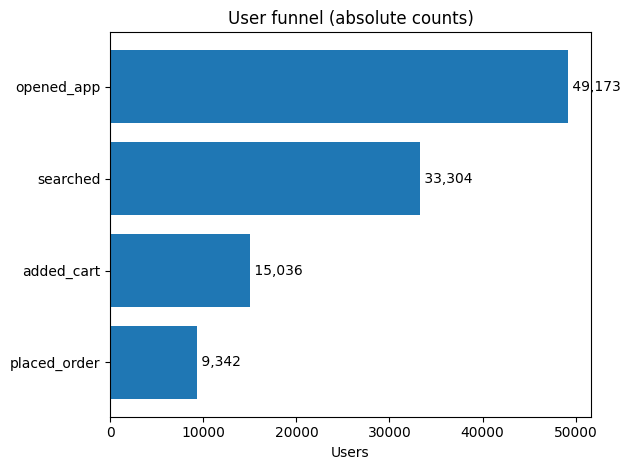

Overall open -> order conversion: 19.0%


In [3]:
plt.barh(funnel["stage"][::-1], funnel["users"][::-1])
plt.title("User funnel (absolute counts)"); plt.xlabel("Users")
for i, v in enumerate(funnel["users"][::-1]):
    plt.text(v, i, f" {v:,}", va="center")
plt.tight_layout(); plt.show()

overall = funnel["users"].iloc[-1] / funnel["users"].iloc[0] * 100
print(f"Overall open -> order conversion: {overall:.1f}%")

### 3. Find the biggest leak
Which step loses the most users? That's where a PM would focus.
`step_conv` is how many survive each step; `100 - step_conv` is the drop-off.

In [4]:
funnel["dropoff_%"] = (100 - funnel["step_conv"]).round(1)
worst = funnel.iloc[1:].sort_values("dropoff_%", ascending=False).iloc[0]
print(funnel[["stage","step_conv","dropoff_%"]].iloc[1:], "\n")
print(f">>> Biggest leak: {worst['stage']} — {worst['dropoff_%']}% of users drop here.")
print(">>> Product hypothesis: users search but don't add to cart — maybe results are")
print("    irrelevant, prices feel high, or delivery times are too long. Worth A/B testing.")

          stage  step_conv  dropoff_%
1      searched       67.7       32.3
2    added_cart       45.1       54.9
3  placed_order       62.1       37.9 

>>> Biggest leak: added_cart — 54.9% of users drop here.
>>> Product hypothesis: users search but don't add to cart — maybe results are
    irrelevant, prices feel high, or delivery times are too long. Worth A/B testing.


### 4. Segment the funnel
Averages hide problems. Does conversion differ by city tier or device?
This is where real product insights live.

In [5]:
def conv_by(col):
    g = users.groupby(col).agg(opened=("opened_app","sum"),
                               ordered=("placed_order","sum"))
    g["conversion_%"] = (g["ordered"] / g["opened"] * 100).round(1)
    return g

print("By city tier:\n", conv_by("city_tier"), "\n")
print("By device:\n", conv_by("device"))

By city tier:
            opened  ordered  conversion_%
city_tier                               
Tier 1      24323     4608          18.9
Tier 2      17433     3307          19.0
Tier 3       7417     1427          19.2 

By device:
          opened  ordered  conversion_%
device                                
Android   34411     6624          19.2
iOS       14762     2718          18.4


### 5. Retention cohorts
Getting one order is easy; **coming back** is the real business. We group users by the
week they signed up (a *cohort*) and track what % are still ordering in later weeks.
Reading a cohort table: each row is a signup week, each column is weeks-since-signup.

In [6]:
converters = users[users["placed_order"]].copy()

def retain(tier):
    base = {"Tier 1":0.50, "Tier 2":0.42, "Tier 3":0.33}[tier]
    weeks = [1.0]                        # week 0 = 100% (everyone ordered once)
    for _ in range(4):
        weeks.append(round(weeks[-1] * (base + rng.uniform(-0.05, 0.05)), 3))
    return weeks

ret = np.array([retain(t) for t in converters["city_tier"]])
cohort = pd.DataFrame(ret, columns=[f"W{i}" for i in range(5)])
cohort["cohort_week"] = converters["signup_week"].values
retention = (cohort.groupby("cohort_week").mean() * 100).round(1)
retention

,W0,W1,W2,W3,W4
cohort_week,,,,,
0,100.0,44.3,19.9,9.2,4.3
1,100.0,44.8,20.5,9.5,4.4
2,100.0,44.4,20.1,9.2,4.3
3,100.0,44.4,20.1,9.2,4.3
4,100.0,44.7,20.4,9.5,4.4
5,100.0,44.6,20.1,9.2,4.3
6,100.0,44.3,20.1,9.3,4.3
7,100.0,44.6,20.3,9.4,4.4
8,100.0,44.6,20.3,9.4,4.4


### 6. Visualise retention decay
The classic retention curve — steep early drop, then it flattens.

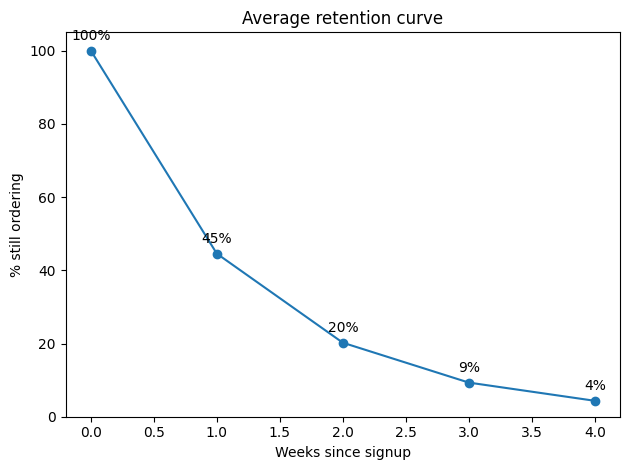

Week 1 retention: 44.5%
Week 4 retention: 4.3%


In [7]:
avg_curve = retention.mean()
plt.plot(range(5), avg_curve.values, marker="o")
plt.title("Average retention curve"); plt.xlabel("Weeks since signup")
plt.ylabel("% still ordering"); plt.ylim(0, 105)
for i, v in enumerate(avg_curve.values):
    plt.text(i, v+3, f"{v:.0f}%", ha="center")
plt.tight_layout(); plt.show()

print(f"Week 1 retention: {retention['W1'].mean():.1f}%")
print(f"Week 4 retention: {retention['W4'].mean():.1f}%")

### Key takeaways (your Zomato talking points)
- **Overall funnel conversion ~19%**; the biggest leak is **search → add-to-cart** (~55% lost) —
  the highest-leverage place for a product fix, and a clear **A/B-test** candidate.
- **Tier-1 cities convert and retain better** than Tier-2/3 — segmentation matters; a single
  average would have hidden this.
- **Retention drops sharply after week 1** (~45% → single digits by week 4), so early
  re-engagement (offers, reminders) is where growth effort should go.
- This mirrors how a Product Analyst works: *measure the funnel → find the leak →
  form a hypothesis → propose an experiment → track retention as the real success metric.*